# PPE: Pliocene Equilibrium Reconstruction

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/glade/work/fengzhu/GitHub/cfr/docsrc/v2026/notebooks')
import numpy as np
import pandas as pd
import xarray as xr
import cfr
cfr.use('v2026')
print(cfr.__version__)
import datetime
print(f'Last update: {datetime.date.today()}')

2026.4.8
Last update: 2026-04-16


## Obs Setup

In [2]:
da_truth = xr.open_dataset('./data/ppe_Plio400ppm_ann.nc')['TEMP'].isel(z_t=0).mean('time')
da_truth

<xarray.DataArray 'TEMP' (nlat: 394, nlon: 320)> Size: 504kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(394, 320), dtype=float32)
Coordinates:
    TLAT     (nlat, nlon) float64 1MB ...
    TLONG    (nlat, nlon) float64 1MB ...
    ULAT     (nlat, nlon) float64 1MB ...
    ULONG    (nlat, nlon) float64 1MB ...
    z_t      float32 4B 500.0
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Potential Temperature (Annual)
    units:         °C
    grid_loc:      3111
    cell_methods:  time: mean
    path:          ['/glade/campaign/univ/uazn0034/fengzhu/CESM_output/timese...
    comp:          ocn
    grid:          g16

In [3]:
R = 0.01
df = pd.read_json(f'./data/ppe_Plio400ppm_obs_SST_R{R:.2f}.json')
obs = cfr.Obs(df)
obs.setup()
obs.df

,pid,lat,lon,time,value,R,type,psm_name
0,DSDP516.Mg/Ca,-30.646322,324.994450,[3.5],[23.1653251648],0.01,T,IdenticalSST
1,DSDP552.Mg/Ca,55.593510,345.982189,[3.5],[17.0483608246],0.01,T,IdenticalSST
2,DSDP590.Mg/Ca,-32.594207,162.898037,[3.5],[22.5412883759],0.01,T,IdenticalSST
3,DSDP603.Mg/Ca,35.261855,290.479297,[3.5],[25.1493167877],0.01,T,IdenticalSST
4,DSDP609.Mg/Ca,49.422589,335.045676,[3.5],[16.7079963684],0.01,T,IdenticalSST
...,...,...,...,...,...,...,...,...
103,ODP959.UK37,3.053953,356.530460,[3.5],[29.6693210602],0.01,T,IdenticalSST
104,ODP978.UK37,35.655501,357.297471,[3.5],[23.1417293549],0.01,T,IdenticalSST
105,ODP982.UK37,57.058493,343.381278,[3.5],[16.6606521606],0.01,T,IdenticalSST
106,ODP999.UK37,12.533555,281.067292,[3.5],[28.507900238],0.01,T,IdenticalSST


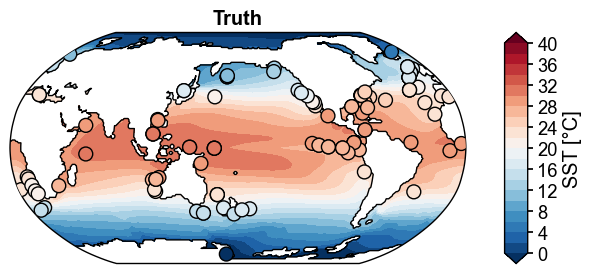

Figure saved at: "figs/ppe_truth_obs.pdf"


In [4]:
cfr.set_style('journal', font_scale=1.2)
fig, ax = obs.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11), 'label': 'SST [°C]'},
    cyclic=True,
    da_target=da_truth.x.regrid(),
    title='Truth',
)
cfr.showfig(fig)
cfr.savefig(fig, './figs/ppe_truth_obs.pdf')

## Prior Setup

In [9]:
pm = []
case_list = ['1xCO2', '350ppm', '490ppm', '2xCO2']
for tag in case_list:
    ds = xr.open_dataset(f'./data/ppe_Plio{tag}_ann.nc')[['TS', 'TEMP']]
    pm.append(cfr.PriorMember(ds.mean('time')))

prior = cfr.Prior(pm)
prior.ds['ens'] = ('ens', case_list)
prior.ds

<xarray.Dataset> Size: 127MB
Dimensions:  (ncol: 48602, ens: 4, z_t: 60, nlat: 394, nlon: 320)
Coordinates:
    lat      (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.68 36.05
    lon      (ncol) float64 389kB 315.0 315.8 317.2 318.0 ... 133.7 136.3 135.0
    TLAT     (nlat, nlon) float64 1MB -84.56 -84.56 -84.56 ... 72.2 72.19 72.19
    TLONG    (nlat, nlon) float64 1MB 320.6 321.7 322.8 ... 318.9 319.4 319.8
    ULAT     (nlat, nlon) float64 1MB -84.3 -84.3 -84.3 ... 72.42 72.41 72.41
    ULONG    (nlat, nlon) float64 1MB 321.1 322.3 323.4 ... 319.2 319.6 320.0
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
  * ens      (ens) <U6 96B '1xCO2' '350ppm' '490ppm' '2xCO2'
Dimensions without coordinates: ncol, nlat, nlon
Data variables:
    TS       (ncol, ens) float32 778kB 19.5 20.37 21.39 ... 19.82 20.87 21.65
    TEMP     (z_t, nlat, nlon, ens) float32 121MB nan nan nan ... nan nan nan

In [10]:
prior.set_hcoords({
    'TS': ('lat', 'lon'),
    # 'PRECT': ('lat', 'lon'),
    # 'PSL': ('lat', 'lon'),
    'TEMP': ('TLAT', 'TLONG'),
    # 'SALT': ('TLAT', 'TLONG'),
    # 'aice': ('TLAT', 'TLONG'),
})

## Run the EnKF Solver

In [11]:
da_solver = cfr.enkf.Solver(prior, obs)

da_solver.prep(
    loc_radius=10000,
    loc_method='gaspari_cohn',
    startover=True,
    get_clim_kws={
        'lat_coord': 'TLAT',
        'lon_coord': 'TLONG',
        'lat_dim': 'nlat',
        'lon_dim': 'nlon',
    },
)

>>> Proxy System Modeling: Y = H(X)
>>> Computing the localization matrix


Processing variables: 100%|██████████| 2/2 [00:01<00:00,  1.03it/s]


In [12]:
da_solver.run(
    method='EnSRF',
)

>>> DA update


Updating time slices:   0%|          | 0/1 [00:00<?, ?it/s]

Updating time slices: 100%|██████████| 1/1 [00:09<00:00,  9.08s/it]


In [13]:
os.makedirs('./recons', exist_ok=True)
da_solver.post.to_netcdf(f'./recons/recon_Plio400ppm_R0.01_loc10000.nc')
da_solver.post

<xarray.Dataset> Size: 248MB
Dimensions:  (time: 1, ncol: 48602, ens: 4, z_t: 60, nlat: 394, nlon: 320)
Coordinates:
    lat      (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.68 36.05
    lon      (ncol) float64 389kB 315.0 315.8 317.2 318.0 ... 133.7 136.3 135.0
  * ens      (ens) <U6 96B '1xCO2' '350ppm' '490ppm' '2xCO2'
    TLAT     (nlat, nlon) float64 1MB -84.56 -84.56 -84.56 ... 72.2 72.19 72.19
    TLONG    (nlat, nlon) float64 1MB 320.6 321.7 322.8 ... 318.9 319.4 319.8
    ULAT     (nlat, nlon) float64 1MB -84.3 -84.3 -84.3 ... 72.42 72.41 72.41
    ULONG    (nlat, nlon) float64 1MB 321.1 322.3 323.4 ... 319.2 319.6 320.0
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
  * time     (time) float64 8B 3.5
Dimensions without coordinates: ncol, nlat, nlon
Data variables:
    TS       (time, ncol, ens) float64 2MB 20.83 20.84 20.86 ... 20.2 20.25
    TEMP     (time, z_t, nlat, nlon, ens) float64 242MB nan nan nan ... nan nan

## Validation

In [14]:
ds_truth = xr.open_dataset('./data/ppe_Plio400ppm_ann.nc').mean('time')
ds_truth

<xarray.Dataset> Size: 66MB
Dimensions:  (ncol: 48602, z_t: 60, nlat: 394, nlon: 320)
Coordinates:
    lat      (ncol) float64 389kB ...
    lon      (ncol) float64 389kB ...
    TLAT     (nlat, nlon) float64 1MB ...
    TLONG    (nlat, nlon) float64 1MB ...
    ULAT     (nlat, nlon) float64 1MB ...
    ULONG    (nlat, nlon) float64 1MB ...
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
Dimensions without coordinates: ncol, nlat, nlon
Data variables:
    TS       (ncol) float32 194kB 20.86 20.63 20.17 19.86 ... 20.23 19.39 20.28
    PRECT    (ncol) float32 194kB 4.232e-08 4.387e-08 ... 7.107e-08 6.165e-08
    TEMP     (z_t, nlat, nlon) float32 30MB nan nan nan nan ... nan nan nan nan
    SALT     (z_t, nlat, nlon) float32 30MB nan nan nan nan ... nan nan nan nan
    aice     (nlat, nlon) float32 504kB nan nan nan nan nan ... nan nan nan nan
    PSL      (ncol) float32 194kB 1.018e+05 1.018e+05 ... 1.017e+05 1.017e+05

In [16]:
ds_post = xr.open_dataset(f'./recons/recon_Plio400ppm_R0.01_loc10000.nc')
ds_post

<xarray.Dataset> Size: 248MB
Dimensions:  (time: 1, ncol: 48602, ens: 4, z_t: 60, nlat: 394, nlon: 320)
Coordinates:
    lat      (ncol) float64 389kB ...
    lon      (ncol) float64 389kB ...
  * ens      (ens) <U6 96B '1xCO2' '350ppm' '490ppm' '2xCO2'
    TLAT     (nlat, nlon) float64 1MB ...
    TLONG    (nlat, nlon) float64 1MB ...
    ULAT     (nlat, nlon) float64 1MB ...
    ULONG    (nlat, nlon) float64 1MB ...
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
  * time     (time) float64 8B 3.5
Dimensions without coordinates: ncol, nlat, nlon
Data variables:
    TS       (time, ncol, ens) float64 2MB ...
    TEMP     (time, z_t, nlat, nlon, ens) float64 242MB ...

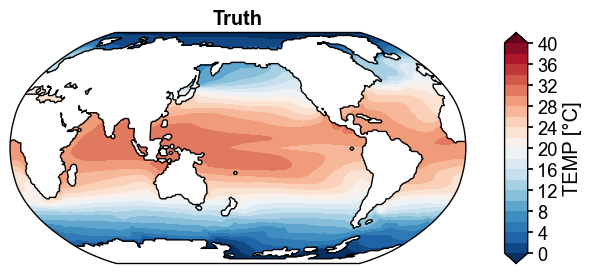

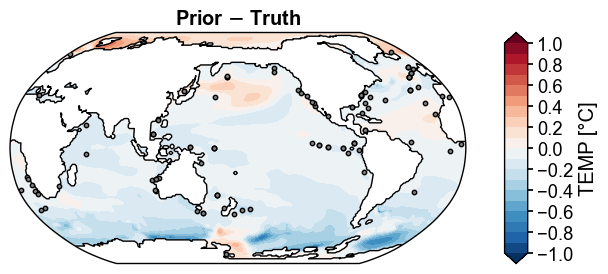

Directory created at: "../figs"
Figure saved at: "../figs/ppe_prior_truth_diff.pdf"


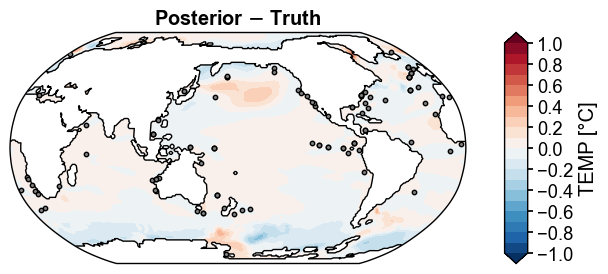

Figure saved at: "../figs/ppe_post_truth_diff.pdf"


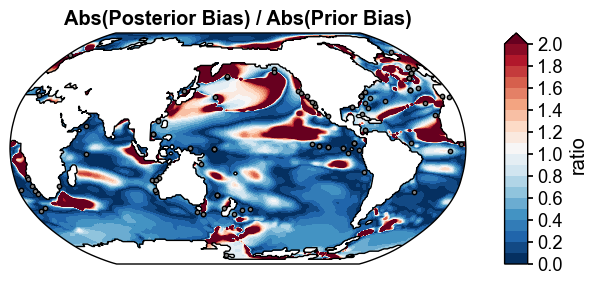

Figure saved at: "figs/ppe_offline_improvement.pdf"


In [17]:
import x4c

vn = 'TEMP'
da_truth = ds_truth[vn].isel(z_t=0).x.regrid()
da_prior = prior.ds[vn].isel(z_t=0).mean('ens').x.regrid()
da_post = ds_post[vn].isel(z_t=0).mean('ens').isel(time=0).x.regrid()

prior_truth = da_prior - da_truth
post_truth = da_post - da_truth

cfr.set_style('journal', font_scale=1.2)
fig, ax = da_truth.x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
    title='Truth',
    cyclic=True,
)

fig, ax = prior_truth.x.plot(
    levels=np.linspace(-1, 1, 21),
    cbar_kwargs={'ticks': np.linspace(-1, 1, 11)},
    title='Prior $-$ Truth',
    df_sites=obs.df[['lat', 'lon']],
    site_markersizes=10,
    legend=False,
    cyclic=True,
)
x4c.showfig(fig)
x4c.savefig(fig, '../figs/ppe_prior_truth_diff.pdf')

fig, ax = post_truth.x.plot(
    levels=np.linspace(-1, 1, 21),
    cbar_kwargs={'ticks': np.linspace(-1, 1, 11)},
    title='Posterior $-$ Truth',
    df_sites=obs.df[['lat', 'lon']],
    site_markersizes=10,
    legend=False,
    cyclic=True,
)
x4c.showfig(fig)
x4c.savefig(fig, '../figs/ppe_post_truth_diff.pdf')

fig, ax = (np.abs(post_truth)/np.abs(prior_truth)).x.plot(
    levels=np.linspace(0, 2, 21),
    extend='max',
    cbar_kwargs={'ticks': np.linspace(0, 2, 11), 'label': 'ratio'},
    title='Abs(Posterior Bias) / Abs(Prior Bias)',
    df_sites=obs.df[['lat', 'lon']],
    site_markersizes=10,
    legend=False,
    cyclic=True,
)
x4c.showfig(fig)
x4c.savefig(fig, './figs/ppe_offline_improvement.pdf')

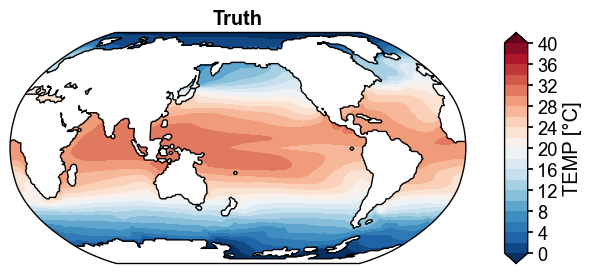

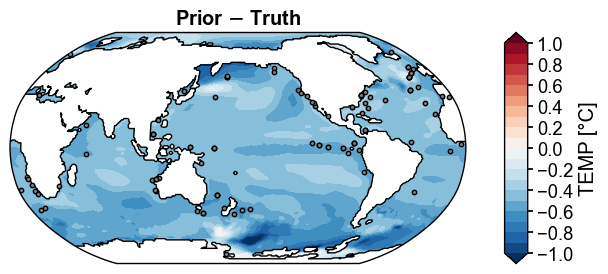

Figure saved at: "../figs/ppe_prior_truth_diff.pdf"


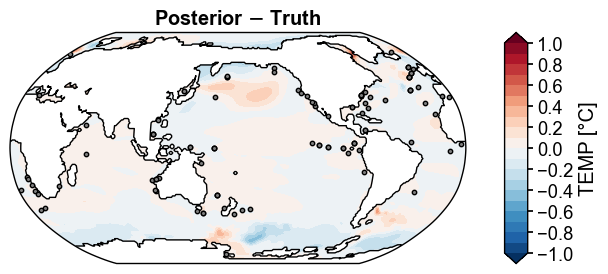

Figure saved at: "../figs/ppe_post_truth_diff.pdf"


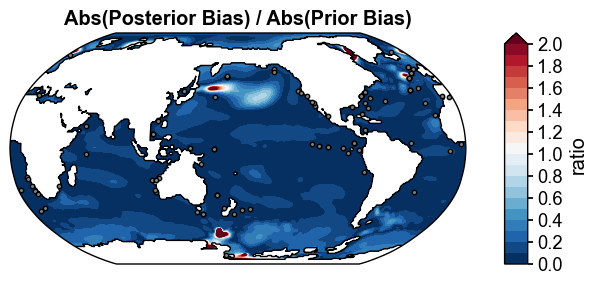

Figure saved at: "figs/ppe_offline_improvement_350ppm.pdf"


In [19]:
vn = 'TEMP'
da_truth = ds_truth[vn].isel(z_t=0).x.regrid()
da_prior = prior.ds[vn].isel(z_t=0).sel(ens='350ppm').x.regrid()
da_post = ds_post[vn].isel(z_t=0).sel(ens='350ppm').isel(time=0).x.regrid()

prior_truth = da_prior - da_truth
post_truth = da_post - da_truth

x4c.set_style('journal', font_scale=1.2)
fig, ax = da_truth.x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
    title='Truth',
    cyclic=True,
)

fig, ax = prior_truth.x.plot(
    levels=np.linspace(-1, 1, 21),
    cbar_kwargs={'ticks': np.linspace(-1, 1, 11)},
    title='Prior $-$ Truth',
    df_sites=obs.df[['lat', 'lon']],
    site_markersizes=10,
    legend=False,
    cyclic=True,
)
x4c.showfig(fig)
x4c.savefig(fig, '../figs/ppe_prior_truth_diff.pdf')

fig, ax = post_truth.x.plot(
    levels=np.linspace(-1, 1, 21),
    cbar_kwargs={'ticks': np.linspace(-1, 1, 11)},
    title='Posterior $-$ Truth',
    df_sites=obs.df[['lat', 'lon']],
    site_markersizes=10,
    legend=False,
    cyclic=True,
)
x4c.showfig(fig)
x4c.savefig(fig, '../figs/ppe_post_truth_diff.pdf')

fig, ax = (np.abs(post_truth)/np.abs(prior_truth)).x.plot(
    levels=np.linspace(0, 2, 21),
    extend='max',
    cbar_kwargs={'ticks': np.linspace(0, 2, 11), 'label': 'ratio'},
    title='Abs(Posterior Bias) / Abs(Prior Bias)',
    df_sites=obs.df[['lat', 'lon']],
    site_markersizes=10,
    legend=False,
    cyclic=True,
)
x4c.showfig(fig)
x4c.savefig(fig, './figs/ppe_offline_improvement_350ppm.pdf')

/glade/work/fengzhu/conda-envs/cfr-py313/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


np.float64(0.9999998434333481)

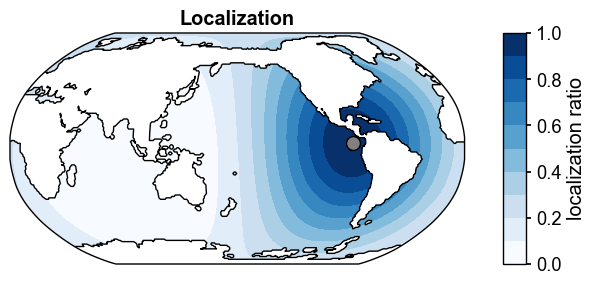

In [20]:
obs_idx = 10
ds_loc = cfr.utils.states2ds(da_solver.L[:, obs_idx], prior.ds.isel(ens=0))
fig, ax = ds_loc['TEMP'].isel(z_t=0).x.regrid().x.plot(
    cmap='Blues',
    levels=np.linspace(0, 1, 11),
    cbar_kwargs={'label': 'localization ratio', 'ticks': np.linspace(0, 1, 6)},
    title='Localization',
    extend='neither',
    df_sites=obs.df[['lat', 'lon']].iloc[[obs_idx]],
    legend=False,
)
np.nanmax(da_solver.L)